# Practicum: Conditional Memory Recall with Masked Stochastic Attention

In [lecture L15a](https://github.com/varnerlab/CHEME-5820-Lectures-Spring-2026/tree/main/lectures/week-15/L15a) and [lab L15b](https://github.com/varnerlab/CHEME-5820-Labs-Spring-2026/tree/main/labs/week-15/L15b) we built a **Spiking Hebbian Memory Network (H-Mem)** that stores associations in a synaptic matrix $\mathbf{W}^{\mathrm{assoc}}$ and recalls them via $\mathbf{v} = \mathbf{W}^{\mathrm{assoc}}\mathbf{k}$, where $\mathbf{k}$ is a key (question) vector and $\mathbf{v}$ is the recalled value (answer). 

The **modern Hopfield network** of [Ramsauer et al. (2020)](https://arxiv.org/abs/2008.02217) generalizes this: stored memories sit on the columns of a memory matrix $\mathbf{X}$ and recall becomes a single softmax-attention update $\mathbf{s} \leftarrow \mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s})$, with an (inverse) temperature $\beta$ that interpolates between Hebbian recall and soft averaging.

Adding Langevin noise to the modern-Hopfield update turns it into a training-free generative sampler — **Stochastic Attention (SA)** — used recently to generate small protein families ([Varner, 2026](https://arxiv.org/abs/2603.14717)) and synthetic patient cohorts ([Varner et al., 2026](https://arxiv.org/abs/2604.07557)) without any model training. We talked about __stochastic attention__ in [lecture L8a](https://github.com/varnerlab/CHEME-5820-Lectures-Spring-2026/tree/main/lectures/week-8/L8a) and [lab L8b](https://github.com/varnerlab/CHEME-5820-Labs-Spring-2026/tree/main/labs/week-8/L8b).

In this practicum, we explore whether SA over a small Hopfield memory of the [Olivetti faces](https://scikit-learn.org/stable/datasets/real_world.html#the-olivetti-faces-dataset) (10 subjects × 10 portraits per subject) acts as a training-free generator of recognizable *new* faces — blends of stored portraits, not copies. We then ask whether a single boolean mask (similar to the idea we used the decoder-only transformers) on the attention softmax is enough to steer that generator to a chosen subject, with no retraining and no change to the architecture.

> __Learning Objectives:__
>
> By the end of this practicum, you should be able to:
> * __Sample from a Hopfield memory with Stochastic Attention:__ Add Langevin noise to the modern-Hopfield update and treat the result as a training-free sampler from the network's energy landscape. Tune the step size, noise scale, and inverse temperature to balance fidelity against novelty in the generated faces.
> * __Steer generation by masking the attention softmax:__ Apply a boolean mask or a finite logit bias to the attention weights to restrict generation to a chosen subset of stored memories. Compare the two strategies and identify the calibration gap between attention-space conditioning and decoded output.
> * __Recover the Hebbian–Hopfield bridge empirically:__ Sweep the inverse temperature inside the masked sampler and read off the transition from soft blend to Hebbian recall in the novelty curve. Connect the high-temperature limit back to the H-Mem read step from [L15](https://github.com/varnerlab/CHEME-5820-Lectures-Spring-2026/tree/main/lectures/week-15).

Let's get started!
___

## Background: From H-Mem to modern Hopfield to Stochastic Attention
The same associative-memory mechanism shows up multiple times across this course.

In [lecture L15a](https://github.com/varnerlab/CHEME-5820-Lectures-Spring-2026/tree/main/lectures/week-15/L15a)/[lab L15b](https://github.com/varnerlab/CHEME-5820-Labs-Spring-2026/tree/main/labs/week-15/L15b) we saw the **spiking H-Mem** of Limbacher and Legenstein ([2020](https://proceedings.neurips.cc/paper/2020/file/f6876a9f998f6472cc26708e27444456-Paper.pdf), [2022/2023](https://arxiv.org/abs/2205.11276)). Memories are written into a synaptic matrix $\mathbf{W}^{\mathrm{assoc}}$ by Hebbian plasticity (the spike-trace outer-product rule), and a key spike train is recalled as $\mathbf{v} = \mathbf{W}^{\mathrm{assoc}}\mathbf{k}$, where $\mathbf{k}$ is the key and $\mathbf{v}$ is the recalled value. 

The **modern Hopfield network** of [Ramsauer et al. (2020)](https://arxiv.org/abs/2008.02217) replaces $\mathbf{W}^{\mathrm{assoc}}$ with the explicit memory matrix $\mathbf{X}$ (one stored pattern per column) and replaces the matrix–vector recall by one closed-form softmax-attention update for query $\mathbf{s}$ given by:
$$\mathbf{s} \;\leftarrow\; \mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s}).$$
In the limit $\beta \to \infty$ the softmax becomes a one-hot, and the update is exactly the Hebbian read step we used in [L15](https://github.com/varnerlab/CHEME-5820-Lectures-Spring-2026/tree/main/lectures/week-15).

**Stochastic Attention (SA)** of [Varner (2026)](https://arxiv.org/abs/2603.14717) treats the modern-Hopfield log-sum-exp energy as a Boltzmann distribution and samples from it by Langevin dynamics, giving the update rule:
$$\mathbf{s}_{t+1} \;=\; (1-\eta)\,\mathbf{s}_{t} + \eta\cdot\mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s}_{t}) \;+\; \sigma\cdot\boldsymbol{\xi}_{t},\qquad \boldsymbol{\xi}_{t}\sim\mathcal{N}(0, \mathbf{I}).$$
where $\eta$ is a step size, $\sigma$ is a noise scale, $\boldsymbol{\xi}_{t}$ is a standard Gaussian noise vector, and $\beta$ is the inverse temperature, $\mathbf{s}_{t}$ is the current sample, $\mathbf{s}_{t+1}$ is the next sample and $\mathbf{X}$ is the memory matrix.
With $\sigma = 0$ and $\eta = 1$ this is the modern-Hopfield update; with $\sigma > 0$ stochastic attention draws novel samples from a smoothed family, training-free.

Let's take this a step further: can we steer the SA generator to a chosen subset of stored memories by masking the attention softmax, with no retraining and no change to the architecture? This is the question we explore in this practicum.

### Why a mask?
Stochastic Attention treats every stored memory equally. To restrict generation to a subset of memories, we add a boolean mask to the softmax: set the logit of every excluded pattern to $-\infty$. This is the masking idea from causal language modeling in transformers, applied to a Hopfield memory rather than a sequence. 

[Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115) showed that a softer version, a finite scalar bias on in-subset logits, also works, and characterized the **calibration gap** between what the sampler steers toward in attention space and what the decoded output looks like.

In this practicum we implement and explore both versions on the Olivetti faces dataset, verify the equivalence of the H-Mem read step and the modern-Hopfield update, and tune the SA hyperparameters to balance fidelity against novelty.
___

## Setup, Data, and Prerequisites

We set up the computational environment by including the [`Include.jl`](Include.jl) file, which sets paths, loads external packages, seeds the RNG, and pulls in the practicum source files from `src/`.

* [`src/Types.jl`](src/Types.jl) defines [`MyModernHopfieldNetworkModel`](src/Types.jl) and [`MyStochasticAttentionModel`](src/Types.jl).
* [`src/Factory.jl`](src/Factory.jl) provides the [`build(...)`](src/Factory.jl) factories.
* [`src/Compute.jl`](src/Compute.jl) implements [`modern_hopfield_recall`](src/Compute.jl), [`stochastic_attention_sample`](src/Compute.jl) (with optional `hard_mask` and `soft_bias` keyword arguments), and [`classify_by_nearest_mean`](src/Compute.jl).
* [`src/Files.jl`](src/Files.jl) ships [`load_olivetti_subset`](src/Files.jl) and [`image_grid`](src/Files.jl).

Let's load the environment.

In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/Practicum-5820-S2026`


### Constants
Let's set some constants that define the problem size and dataset parameters. The comment next to each constant describes its purpose and values:

In [2]:
n_subjects, images_per_subject, β_gen, β_cond = let

    # initialize -
    n_subjects = 10;          # TODO: how many of the 40 Olivetti subjects to memorize (Int 1..40)
    images_per_subject = 10;  # TODO: how many portraits per subject (Int 1..10)
    β_gen = 0.02;             # TODO: SA temperature for Task 1 (unconditional generation). Try 0.01, 0.02, 0.05.
    β_cond = 8.0;             # TODO: SA temperature for Task 2 (masked / soft-biased). Try 4.0, 8.0, 32.0.

    # return -
    n_subjects, images_per_subject, β_gen, β_cond;
end;

### Data

The [Olivetti faces dataset](https://scikit-learn.org/stable/datasets/real_world.html#the-olivetti-faces-dataset) has 40 subjects × 10 portraits each, 64 × 64 pixel grayscale. We've downloaded them and stored the files in the `data/olivetti/{faces,targets}.csv` in this repository. 

The helper function [`load_olivetti_subset(...)`](src/Files.jl) reads `images_per_subject::Int` portraits from each of the first `n_subjects::Int` people, flattens each image into a length-`4096` vector, and stacks them as columns of a single memory matrix $\mathbf{X}$. The companion vector $\mathbf{y}$ records the integer subject id of each column.

The cell below loads the data into `X::Matrix{Float64}` and `y::Vector{Int}`.

In [3]:
# let's load up the face data -
X, y = load_olivetti_subset(images_per_subject; n_subjects = n_subjects);
println("loaded $(size(X, 2)) faces of dimension $(size(X, 1)) covering $(length(unique(y))) subjects")

loaded 100 faces of dimension 4096 covering 10 subjects


__Test__: Before continuing, lets confirm that we have a `4096 × N` memory matrix with one subject id per column and `n_subjects::Int` distinct subjects present. If any of these checks fail, an [AssertionError](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError) will be raised, and you should go back and check the data loading step.

In [4]:
let
    @assert size(X, 1) == 4096                                # 64 × 64 pixels per face
    @assert size(X, 2) == n_subjects * images_per_subject
    @assert length(y) == size(X, 2)                           # one subject id per column
    @assert sort(unique(y)) == collect(0:(n_subjects - 1))    # the first n_subjects subjects, 0..n_subjects-1
end

__Did we blow up?__ If not, let's peek at one portrait of every subject we loaded, to confirm the data made it in correctly. If everything looks good, we should see a grid of 10 faces, each from a different subject.

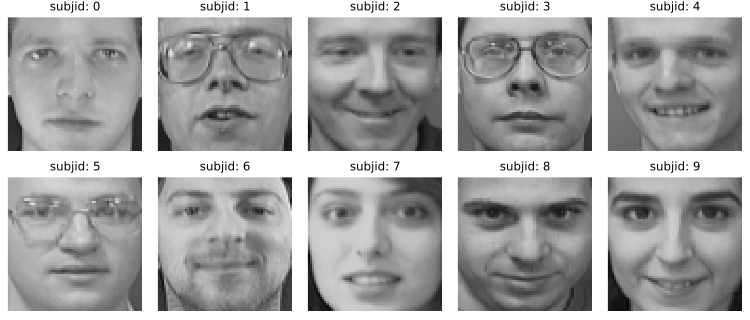

In [5]:
# Preview: one portrait per subject — laid out in a balanced grid with per-tile subject ids.
let
    ncols = 5
    nrows = cld(n_subjects, ncols)
    plots = [];
    for s in 0:(n_subjects - 1)
        idx = findfirst(==(s), y);
        img  = Gray.(reshape(X[:, idx], 64, 64));
        push!(plots, heatmap(img, color = :grays, axis = false, ticks = false,
            title = "subjid: $s", titlefontsize = 8, aspect_ratio = :equal));
    end
    for _ in (n_subjects + 1):(nrows * ncols)
        push!(plots, plot(framestyle = :none));
    end
    plot(plots...; layout = (nrows, ncols),
        size = (150 * ncols, 160 * nrows),
        margin = 0Plots.PlotMeasures.mm)
end

### Build the SA models and reference classifier
Next, let's construct three objects for reuse throughout the notebook:
* `sa_gen::MyStochasticAttentionModel` — SA sampler at $\beta_{\mathrm{gen}}$ for unconditional generation (Task 1).
* `sa_cond::MyStochasticAttentionModel` — SA sampler at $\beta_{\mathrm{cond}}$ for conditional generation (Task 2).
* `class_means::Dict{Int, Vector{Float64}}` — per-subject centroids of the stored portraits, used as a training-free reference classifier in Task 2. This is computed by [`build_class_means(X, y)` function](src/Compute.jl), which groups the columns of $\mathbf{X}$ by their subject id in $\mathbf{y}$ and averages within each group: $\mathbf{c}_k = \tfrac{1}{|\{j : y_j = k\}|}\sum_{j : y_j = k}\mathbf{X}_{:,j}$. The result is one length-`4096` mean vector per unique subject id.

The [`build(...)` factories](src/Factory.jl) for the SA samplers live in [`src/Factory.jl`](src/Factory.jl); [`build_class_means`](src/Compute.jl) lives in [`src/Compute.jl`](src/Compute.jl).

In [29]:
sa_gen, sa_cond, class_means = let

    # initialize -
    sa_gen = nothing; # we initialize these to `nothing` so the factory functions can fill them in
    sa_cond = nothing;
    class_means = nothing;

    # build the unconditional SA sampler (Task 1) -
    sa_gen = build(MyStochasticAttentionModel, (
        memories     = X, # the memory matrix is the data matrix, with one portrait per column
        labels       = y, # the subject id of each portrait, used for evaluation but not used by the model
        β            = β_gen, # the inverse temperature for the SA sampler
        step_size    = 1.0,  # TODO: try 0.25, 0.5, 1.0
        noise_scale  = 0.10, # TODO: try 0.02 (regurgitation), 0.10, 0.30
    ));

    # build the masked / soft-bias SA sampler (Task 2) -
    sa_cond = build(MyStochasticAttentionModel, (
        memories     = X,
        labels       = y,
        β            = β_cond,
        step_size    = 1.0,
        noise_scale  = 0.10,
    ));

    # compute the per-subject means for later evaluation -
    class_means = build_class_means(X, y);

    # return -
    sa_gen, sa_cond, class_means;
end;

___

## Task 1: Stochastic Attention sampling on faces
In this task, we ask whether adding a Gaussian-noise term to the modern-Hopfield update, no training, no GPU, no learned weights, turns it into a generative model that produces new faces we never stored. 

The modern-Hopfield update returns one of the stored columns of $\mathbf{X}$ (in the high-$\beta$ limit, exactly one; at moderate $\beta$, a softmax mixture sharply concentrated on one). A pure recall loop cannot generate anything new. Stochastic Attention adds a Gaussian noise term so the update samples from a Boltzmann distribution rather than collapsing to a stored memory:

$$\underbrace{\mathbf{s}_{t+1} \;=\; (1-\eta)\,\mathbf{s}_{t} + \eta\cdot\mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s}_{t})}_{\text{modern-Hopfield update}} \;+\; \underbrace{\sigma\cdot\boldsymbol{\xi}_{t}}_{\text{the new term}},\qquad \boldsymbol{\xi}_{t}\sim\mathcal{N}(0, \mathbf{I}).$$

The two knobs we tune in this task are the step size $\eta$ (`step_size`) and the noise scale $\sigma$ (`noise_scale`): together they trade fidelity (samples close to stored portraits) against novelty (samples that differ from any single stored portrait). See the [L8a lecture notes](https://github.com/varnerlab/CHEME-5820-Lectures-Spring-2026/tree/main/lectures/week-8/L8a) for a derivation.

The cell below runs Task 1's first simulation: it builds the warm-start matrix, runs 3000 Langevin steps per chain, and stores the results in `unmasked_samples`.

In [7]:
n_samples_unmasked, unmasked_initial, unmasked_samples = let

    # initialize -
    n_samples_unmasked = 10;

    # build the warm-start matrix EXPLICITLY so we can show start vs final per chain.
    # Each column is a random stored portrait plus a small Gaussian kick.
    unmasked_initial = sa_initial_states(sa_gen, n_samples_unmasked);

    # run n_steps Langevin steps starting from unmasked_initial. At β_gen = 0.02
    # the softmax is soft enough that the chain mixes between portraits, so the
    # final noise-free read-out (denoise = true) returns a clean blend of memories
    # rather than collapsing onto a single stored portrait.
    unmasked_samples = stochastic_attention_sample(sa_gen, n_samples_unmasked;
        n_steps = 3000, sₒ = unmasked_initial);

    # return -
    n_samples_unmasked, unmasked_initial, unmasked_samples;
end

(10, [0.22042986077871146 0.13330814801966512 … 0.6734212802518158 0.1713906961953948; 0.1920936014415522 0.24691973406941894 … 0.7574860696722592 0.17967447760318317; … ; 0.16737663595886795 0.24031238877872071 … 0.16619744887025378 0.4570020818883412; 0.12734313669334574 0.19837289244582876 … 0.17197793816636056 0.5069373784735727], [0.5070576425525991 0.5065882050878556 … 0.5069065262561164 0.5049498330392269; 0.5064185000786012 0.5058836339369156 … 0.5061977648414028 0.5042947425747202; … ; 0.6180414662148616 0.6170797774192334 … 0.6181466084048549 0.6176705742346561; 0.6211399069773631 0.6201476956347562 … 0.6212068447589437 0.6207662883402141])

Now, lets see what we got. The cell below visualizes the samples in `unmasked_samples` as a grid of faces, and prints the median nearest-stored distance of the samples, which quantifies how novel they are compared to the stored portraits.

> __What should we expect to see?__
>
> Ten recognizable faces with visible novelty (blends of stored portraits), and a median nearest-stored distance comparable to the typical pairwise distance between stored portraits — meaning samples are genuinely new, not regurgitated.

So what do we see? Do the samples look like recognizable faces? 

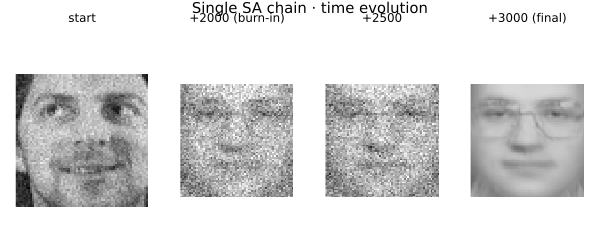

In [8]:
# Time evolution of one SA chain: start → after burn-in → a few more steps → collected sample.
let
    chain_idx = 1                                    # which warm-start chain to follow
    sₒ      = unmasked_initial[:, chain_idx:chain_idx]
    s_burn  = stochastic_attention_sample(sa_gen, 1; n_steps = 2000, sₒ = sₒ,      denoise = false)
    s_more  = stochastic_attention_sample(sa_gen, 1; n_steps =  500, sₒ = s_burn,  denoise = false)
    s_final = stochastic_attention_sample(sa_gen, 1; n_steps =  500, sₒ = s_more,  denoise = true)
    grid = hcat(sₒ, s_burn, s_more, s_final)
    image_grid(grid, 4; tile_px = 150,
        tile_titles = ["start", "+2000 (burn-in)", "+2500", "+3000 (final)"],
        title = "Single SA chain · time evolution")
end

__What to look for.__ Read the four tiles left to right as a single chain's trajectory:

* __start__: the warm-start state — a randomly chosen stored portrait plus a small Gaussian kick. Recognizable as one of the stored faces.
* __+2000 (burn-in)__: the chain after 2000 Langevin steps. The score-function term has pulled the state toward a Boltzmann mode, and the noise term has let it sample around that mode. If the SA hyperparameters are well-tuned, this tile should already look face-like but not identical to the start.
* __+2500__: a few hundred steps after burn-in, showing that the chain keeps moving and is not stuck on a single attractor.
* __+3000 (final)__: the collected sample after one final noise-free read-out (`denoise = true`), which projects the state onto the convex hull of stored patterns and cleans up residual noise.

If all four tiles look identical (or all four are the same blurry "mean face"), the chain has collapsed — raise `noise_scale` or $\beta$ in Setup so the chain explores distinct basins.

Pick a chain index in `1:n_samples_unmasked`. The cell below shows the starting state (a random stored portrait plus a small Gaussian kick) next to where the chain ended up after `n_steps = 3000` updates. A healthy chain settles between portraits rather than snapping back to its starting image; try a few different `chain_index` values to see typical motion.

unconditional · chain 1


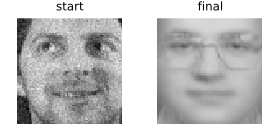

In [9]:
chain_index = let
    chain_index = 1; # TODO: pick a chain index in 1:n_samples_unmasked
    @assert 1 <= chain_index <= n_samples_unmasked
    chain_index;
end
println("unconditional · chain $chain_index")

let
    grid = hcat(unmasked_initial[:, chain_index], unmasked_samples[:, chain_index])
    image_grid(grid, 2; tile_px = 140,
        tile_titles = ["start", "final"])
end

For each generated sample, we compute the distance to its nearest stored portrait under $\|\cdot\|_{2}$, then compare the median to the typical pairwise distance between stored portraits. Three regimes are possible:

* If `nearest-stored ≪ pairwise`, the sampler is producing copies of stored portraits — raise $\sigma$ or lower $\beta$.
* If `nearest-stored ≈ pairwise`, generated samples sit at typical inter-portrait distance from stored memories — they are novel faces.
* If `nearest-stored ≫ pairwise`, the chains have wandered off the data manifold — too much noise.

The cell below computes both medians and prints them.

In [10]:
let
    nearest_dist = Float64[]
    for k in 1:size(unmasked_samples, 2)
        s = unmasked_samples[:, k]
        push!(nearest_dist, minimum(norm(s .- X[:, j]) for j in 1:size(X, 2)))
    end
    Nstored = size(X, 2)
    pairs_n = min(50, Nstored)
    pairwise_sample = [norm(X[:, i] .- X[:, j]) for i in 1:pairs_n for j in (i + 1):pairs_n]
    println("median nearest-stored distance for SA samples: $(round(median(nearest_dist), digits=3))")
    println("median pairwise distance among stored portraits: $(round(median(pairwise_sample), digits=3))")
end

median nearest-stored distance for SA samples: 3.157
median pairwise distance among stored portraits: 10.394


___

## Task 2: Subject-conditional generation by masking the softmax

In this task, we condition generation on a chosen subject without retraining or rebuilding the model. The Boltzmann distribution over states is fully determined by the softmax over stored memories, so to condition the sampler on a subject we only need to change the softmax logits — the body of the chain stays identical. We compare two ways of doing it:

1. **Hard mask.** Set the logit of every off-subject memory to $-\infty$:
   $$\mathrm{logit}_{j} \;=\; \beta\cdot\mathbf{X}_{:,j}^{\top}\mathbf{s} \;+\; \begin{cases} 0 & \text{if }y_{j} = \text{target} \\ -\infty & \text{otherwise}\end{cases}$$
   The exponential sends every off-subject entry to exactly $0$, so the softmax distribution lives entirely on the in-subject portraits.
2. **Soft bias.** Add a finite scalar bonus $b$ to in-subject logits and leave off-subject logits alone. With a large $b$ the soft version approaches the hard mask; at $b = 0$ it reduces to the unconditional sampler. [Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115) shows that even at very large $b$ the soft version can fail to reach the hard-mask hit rate — the **calibration gap**.

> __What should we expect to see?__
>
> The hard mask gives subject-conditional samples at near-perfect hit rate. The soft bias under-performs, with a calibration gap that persists even at large bias.

The cell below generates a batch of target-subject samples under the hard mask and plots them. The mask is a single `Vector{Bool}` of length $N$ passed at sample time; no model retraining, no rebuilding.

In [11]:
target_class, n_samples_class, class_mask = let

    # initialize -
    target_class = 2;          # TODO: which subject id to generate (0..n_subjects-1)
    n_samples_class = 10;      # TODO: how many samples per subject (note: only $images_per_subject stored portraits per subject)
    class_mask = [yj == target_class for yj in y];
    println("class_mask leaves ", count(class_mask), " of ", length(class_mask), " stored portraits visible")

    # return -
    target_class, n_samples_class, class_mask;
end

class_mask leaves 10 of 100 stored portraits visible


(2, 10, Bool[0, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [12]:
class_initial, class_samples = let

    # build the warm-start matrix EXPLICITLY (drawn only from in-subject memories
    # because we pass hard_mask = class_mask) so we can show start vs final per chain.
    class_initial = sa_initial_states(sa_cond, n_samples_class; hard_mask = class_mask);

    # generate the subject-conditional samples via the hard mask, starting from class_initial -
    class_samples = stochastic_attention_sample(sa_cond, n_samples_class;
        n_steps = 3000, hard_mask = class_mask, sₒ = class_initial);

    # return -
    class_initial, class_samples;
end

([0.2006707097511979 0.15520079390481176 … 0.6684548438397149 0.44878190262684486; 0.12151446801967485 0.17023752697199326 … 0.55999274999953 0.48831020414501636; … ; 0.4177823743314618 0.4722948393198739 … 0.39816114584595397 0.23843171210679426; 0.34706804258526747 0.392496199327561 … 0.21816740811703508 0.1573597323883959], [0.494118 0.494118 … 0.513725 0.494118; 0.462745 0.462745 … 0.498039 0.462745; … ; 0.203922 0.203922 … 0.207843 0.203922; 0.192157 0.192157 … 0.215686 0.192157])

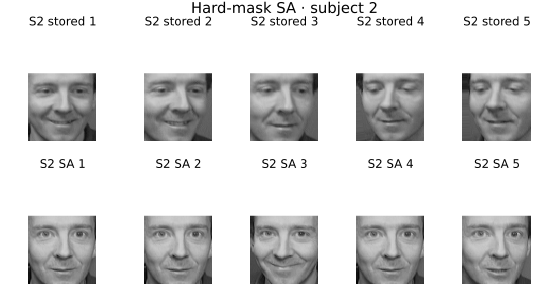

In [13]:
# Compare stored portraits OF the target subject (top row) with hard-mask SA samples (bottom row).
let
    n_show = 5
    target_idx = findall(==(target_class), y)
    stored_target = X[:, target_idx[1:min(n_show, length(target_idx))]]
    sa_target = class_samples[:, 1:n_show]
    grid = hcat(stored_target, sa_target)
    titles = vcat(
        ["S$(target_class) stored $i" for i in 1:n_show],
        ["S$(target_class) SA $i"     for i in 1:n_show]
    )
    image_grid(grid, n_show;
        title = "Hard-mask SA · subject $(target_class)",
        tile_titles = titles)
end

__What to look for.__ Both rows should look like subject `target_class`. The top row is real portraits of that subject; the bottom row is hard-mask SA samples. The hard mask blocks every off-subject memory exactly, so SA cannot drift to a different person. Stylistic variation across the bottom row (different shots blended) is fine and expected.

Pick a chain index in `1:n_samples_class`. The cell below shows the starting state (a random in-subject stored portrait plus a small Gaussian kick) next to where the chain ended up after 3000 masked Langevin steps. Because every off-subject memory has logit $-\infty$, both tiles should be the requested subject — the final tile differs from the start only because the chain has mixed across in-subject portraits.

subject 2 · chain 1


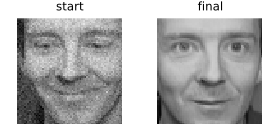

In [14]:
class_chain_index = let
    class_chain_index = 1; # TODO: pick a chain index in 1:n_samples_class
    @assert 1 <= class_chain_index <= n_samples_class
    class_chain_index;
end
println("subject $target_class · chain $class_chain_index")

let
    grid = hcat(class_initial[:, class_chain_index], class_samples[:, class_chain_index])
    image_grid(grid, 2; tile_px = 140,
        tile_titles = ["start", "final"])
end

### Fidelity check

We label each sample by its closest per-subject centroid in pixel space under $\|\cdot\|_{2}$. The centroids `class_means::Dict{Int, Vector{Float64}}` were precomputed in the Setup section.

The cell below loops over all `n_subjects` subjects, draws `n_samples_class` samples each under the hard mask, and reports the fraction that the classifier maps back to the requested subject. Results land in `hardmask_table::DataFrame`.

In [15]:
hardmask_table = let
    df = DataFrame(target = Int[], hits = Int[], total = Int[], hit_rate = Float64[])
    for c in 0:(n_subjects - 1)
        m = [yj == c for yj in y]
        samples = stochastic_attention_sample(sa_cond, n_samples_class;
            n_steps = 3000, hard_mask = m)
        labels = [classify_by_nearest_mean(samples[:, k], class_means) for k in 1:n_samples_class]
        h = count(==(c), labels)
        push!(df, (target = c, hits = h, total = n_samples_class, hit_rate = h / n_samples_class))
    end

    # table -
    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );

    df; # return
end;

 -------- ------- ------- ----------
  target    hits   total   hit_rate 
   Int64   Int64   Int64    Float64 
 -------- ------- ------- ----------
       0      10      10        1.0
       1      10      10        1.0
       2      10      10        1.0
       3      10      10        1.0
       4      10      10        1.0
       5      10      10        1.0
       6      10      10        1.0
       7       9      10        0.9
       8      10      10        1.0
       9       0      10        0.0
 -------- ------- ------- ----------


### Hard mask vs. soft bias: the calibration gap

A hard mask zeros off-subject logits exactly. A soft bias adds a finite scalar bonus to in-subject logits and leaves off-subject logits in play. With a large bias the soft version approaches the hard version, but as [Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115) shows, the interpolation does not always land where we expect in pixel space — that gap is the **calibration gap**.

The cell below sweeps the bias and stores the bias-versus-hit-rate table in `softbias_table::DataFrame`.

In [16]:
softbias_table = let
    
    
    df = DataFrame(bias = Float64[], target = Int[], hits = Int[], total = Int[], hit_rate = Float64[])
    in_class = [yj == target_class for yj in y]
    for b in [0.0, 1.0, 5.0, 20.0, 100.0]
        sb_vec = Float64.([m ? b : 0.0 for m in in_class])
        samples = stochastic_attention_sample(sa_cond, n_samples_class;
            n_steps = 3000, soft_bias = sb_vec)
        labels = [classify_by_nearest_mean(samples[:, k], class_means) for k in 1:n_samples_class]
        h = count(==(target_class), labels)
        push!(df, (bias = b, target = target_class, hits = h, total = n_samples_class, hit_rate = h / n_samples_class))
    end
    
    # table -
    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );

    df; # return -
end;

 --------- -------- ------- ------- ----------
     bias   target    hits   total   hit_rate 
  Float64    Int64   Int64   Int64    Float64 
 --------- -------- ------- ------- ----------
      0.0        2       0      10        0.0
      1.0        2       0      10        0.0
      5.0        2       0      10        0.0
     20.0        2       0      10        0.0
    100.0        2       0      10        0.0
 --------- -------- ------- ------- ----------


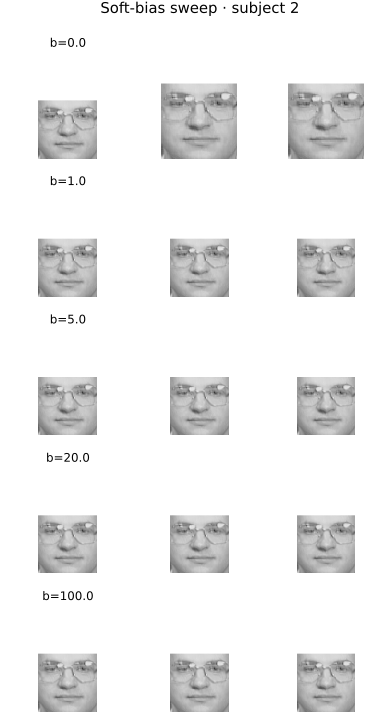

In [17]:
# Visualize one batch from each bias setting, one row per bias level.
let
    biases = [0.0, 1.0, 5.0, 20.0, 100.0]
    n_per = 3
    grid_cols = Vector{Vector{Float64}}()
    titles = String[]
    in_class = [yj == target_class for yj in y]
    for b in biases
        sb_vec = Float64.([m ? b : 0.0 for m in in_class])
        s = stochastic_attention_sample(sa_cond, n_per; n_steps = 3000, soft_bias = sb_vec)
        for k in 1:n_per
            push!(grid_cols, s[:, k])
            push!(titles, k == 1 ? "b=$(b)" : "")
        end
    end
    G = reduce(hcat, grid_cols)
    image_grid(G, n_per;
        title = "Soft-bias sweep · subject $(target_class)",
        tile_titles = titles,
        tile_px = 130)
end

___

## Task 3: $\beta$-sweep — the Hebbian/Hopfield bridge under a mask

In this task, we measure the bridge between the modern-Hopfield update and the H-Mem read step from [L15](https://github.com/varnerlab/CHEME-5820-Lectures-Spring-2026/tree/main/lectures/week-15). The intro asserted that at low $\beta$ the masked sampler returns soft blends of stored memories, while at high $\beta$ it collapses to a single stored column (the Hebbian limit). Sweeping $\beta_{\mathrm{cond}}$ inside the masked sampler turns that narrative into a measurable curve.

We hold the subject mask, the chain length, and the noise schedule fixed at the Task 2 settings. The only knob we sweep is $\beta_{\mathrm{cond}}$, across a logarithmic grid from very soft to very sharp. For each $\beta$ we build a fresh `MyStochasticAttentionModel` over the same memory bank `X`, run masked Langevin chains for the target subject, and compute two diagnostics:

* **Hit rate via nearest-mean classifier**, the fidelity score from Task 2. The hard mask blocks every off-subject memory regardless of $\beta$, so hit rate should stay flat across the sweep.
* **Median nearest-stored distance** $\min_{j}\|\mathbf{s} - \mathbf{X}_{:,j}\|_{2}$, the novelty proxy from Task 1. At low $\beta$ this stays moderate (the chain settles near a convex blend of stored portraits); at high $\beta$ it falls toward $0$ (the chain collapses onto a stored column).

> __What should we expect to see?__
>
> Hit rate stays flat across the sweep — the mask, not $\beta$, enforces conditioning. The median nearest-stored distance falls smoothly from soft blend at low $\beta$ to near-replica at high $\beta$. That descent is the bridge.

The cell below runs the sweep and stores results in `bridge_table::DataFrame`, along with `bridge_samples_low` and `bridge_samples_high` for side-by-side display.

In [18]:
β_grid, bridge_table, bridge_samples_low, bridge_samples_high = let

    # initialize -
    β_grid = [0.005, 0.02, 0.1, 0.5, 2.0, 8.0, 32.0, 128.0]; # TODO: try a denser or wider grid
    df = DataFrame(β = Float64[], hit_rate = Float64[], median_nearest_stored = Float64[])
    bridge_samples_low  = nothing
    bridge_samples_high = nothing

    # sweep β with everything else fixed -
    for (i, β) ∈ enumerate(β_grid)
        sa_β = build(MyStochasticAttentionModel, (
            memories     = X,
            labels       = y,
            β            = β,
            step_size    = sa_cond.step_size,
            noise_scale  = sa_cond.noise_scale,
        ))
        samples = stochastic_attention_sample(sa_β, n_samples_class;
            n_steps = 3000, hard_mask = class_mask)
        labels = [classify_by_nearest_mean(samples[:, k], class_means) for k in 1:n_samples_class]
        hit_rate = count(==(target_class), labels) / n_samples_class
        nearest = [minimum(norm(samples[:, k] .- X[:, j]) for j in 1:size(X, 2))
                   for k in 1:n_samples_class]
        push!(df, (β = β, hit_rate = hit_rate, median_nearest_stored = median(nearest)))
        i == 1                && (bridge_samples_low  = samples)
        i == length(β_grid)   && (bridge_samples_high = samples)
    end

    # table -
    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );

    # return -
    β_grid, df, bridge_samples_low, bridge_samples_high;
end;

 --------- ---------- -----------------------
        β   hit_rate   median_nearest_stored 
  Float64    Float64                 Float64 
 --------- ---------- -----------------------
    0.005        1.0                 4.79753
     0.02        1.0                 2.77363
      0.1        1.0                 1.49031
      0.5        1.0               0.0330948
      2.0        1.0              2.19303e-8
      8.0        1.0                     0.0
     32.0        1.0                     0.0
    128.0        1.0                     0.0
 --------- ---------- -----------------------


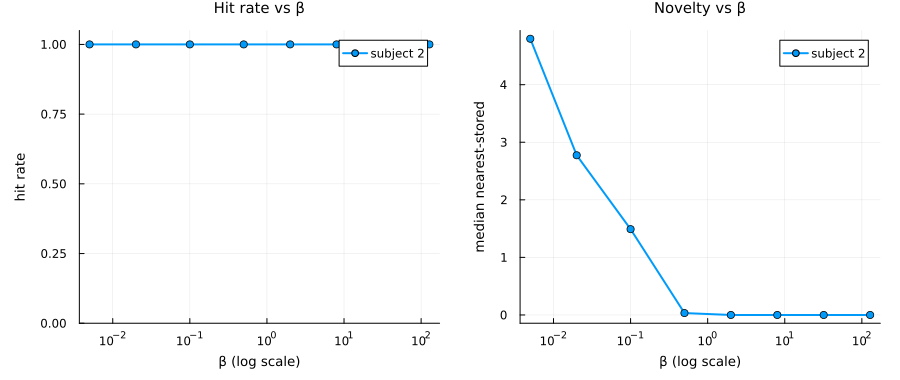

In [19]:
# Two-panel diagnostic: hit rate (flat) and novelty (descending) vs β.
let
    p1 = plot(bridge_table.β, bridge_table.hit_rate;
        xscale = :log10, marker = :circle, lw = 2, ylim = (0.0, 1.05),
        xlabel = "β (log scale)", ylabel = "hit rate",
        label = "subject $(target_class)",
        title = "Hit rate vs β",
        titlefontsize = 10, labelfontsize = 9, tickfontsize = 8, legendfontsize = 8)
    p2 = plot(bridge_table.β, bridge_table.median_nearest_stored;
        xscale = :log10, marker = :circle, lw = 2,
        xlabel = "β (log scale)", ylabel = "median nearest-stored",
        label = "subject $(target_class)",
        title = "Novelty vs β",
        titlefontsize = 10, labelfontsize = 9, tickfontsize = 8, legendfontsize = 8)
    plot(p1, p2; layout = (1, 2), size = (900, 380),
        left_margin = 6Plots.PlotMeasures.mm,
        bottom_margin = 6Plots.PlotMeasures.mm,
        top_margin = 3Plots.PlotMeasures.mm,
        right_margin = 3Plots.PlotMeasures.mm)
end

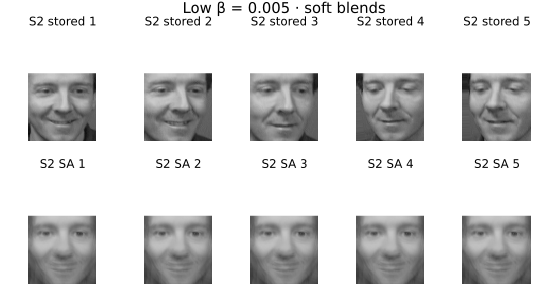

In [20]:
# Low-β: compare stored portraits of the target (top) with low-β masked SA samples (bottom).
let
    n_show = 5
    target_idx = findall(==(target_class), y)
    stored_target = X[:, target_idx[1:min(n_show, length(target_idx))]]
    sa_low = bridge_samples_low[:, 1:n_show]
    grid = hcat(stored_target, sa_low)
    titles = vcat(
        ["S$(target_class) stored $i" for i in 1:n_show],
        ["S$(target_class) SA $i"     for i in 1:n_show]
    )
    image_grid(grid, n_show;
        title = "Low β = $(β_grid[1]) · soft blends",
        tile_titles = titles)
end

__What to look for.__ At low $\beta$, the masked softmax is nearly uniform over in-subject memories, so each SA sample (bottom) is a soft *average* of all stored portraits of the subject — features look smoothed, identity is preserved but specific shots are not.

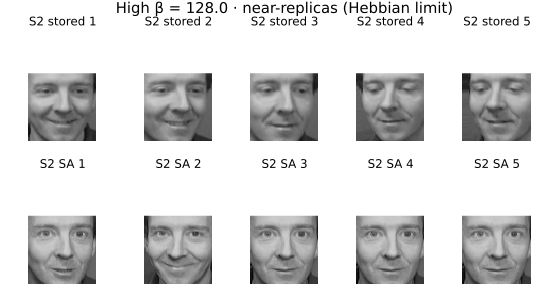

In [21]:
# High-β: compare stored portraits of the target (top) with high-β masked SA samples (bottom).
let
    n_show = 5
    target_idx = findall(==(target_class), y)
    stored_target = X[:, target_idx[1:min(n_show, length(target_idx))]]
    sa_high = bridge_samples_high[:, 1:n_show]
    grid = hcat(stored_target, sa_high)
    titles = vcat(
        ["S$(target_class) stored $i" for i in 1:n_show],
        ["S$(target_class) SA $i"     for i in 1:n_show]
    )
    image_grid(grid, n_show;
        title = "High β = $(β_grid[end]) · near-replicas (Hebbian limit)",
        tile_titles = titles)
end

__What to look for.__ At high $\beta$, the masked softmax concentrates on whichever in-subject memory is closest to the current state, so each SA sample (bottom) collapses to a *replica* of one specific stored portrait. Compare bottom-row tiles to top-row tiles: most bottom samples should be near-copies of one of the top samples (the **Hebbian recall** limit).

___
<a id="discussion"></a>

## Discussion

Answer each question in the comment block below it, then set the corresponding `did_I_answer_DQ*` flag to `true`.

**DQ1: Fidelity vs. novelty in Stochastic Attention.** Re-running Task 1 across different combinations of $\beta$, `step_size`, and `noise_scale` produces faces that range from copies of stored portraits to noise that no longer resembles a face. Sketch the trade-off and explain why a sweet spot exists.

> __Strategy:__
>
> Run Task 1 a few times with different combinations. Watch what happens at $\beta = 64$ and at `noise_scale = 0.5`. Explain the trade-off in terms of the SA energy landscape: think about the depth and width of the energy basins around stored portraits at different $\beta$, and what `noise_scale` is doing to a chain inside a basin. Identify the regime where samples look like faces but are not copies of the training set.

In [22]:
#= Put your answer to DQ1 here. =#

In [23]:
did_I_answer_DQ1 = false; # set to `true` after answering DQ1

**DQ2: Why does soft bias under-perform a hard mask?** A boolean mask reaches near-perfect subject-conditional hit rate, but a finite scalar bias on in-subject logits often does not, even at bias = 100. Explain the calibration gap.

> __Strategy:__
>
> Compare the hard-mask and soft-bias hit-rate tables side by side. For low bias, why does the hit rate barely move? Think about the magnitude of the inner-product term $\beta\cdot\mathbf{X}^{\top}\mathbf{s}$ versus the additive bias on a 4096-dimensional state. For high bias, why does the soft version still miss? Connect this to the **calibration gap** of [Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115): conditioning is exact at the level of the sampler's softmax weights, but the decoded sample can disagree because the inner-product term steers the chain toward whichever attractor is closest, regardless of subject.

In [24]:
#= Put your answer to DQ2 here. =#

In [25]:
did_I_answer_DQ2 = false; # set to `true` after answering DQ2

**DQ3: What does the $\beta$-sweep recover empirically?** Across the $\beta$-grid, hit rate stays flat but median nearest-stored distance falls smoothly. Explain what this curve is and where the transition between the two regimes happens.

> __Strategy:__
>
> Read the `bridge_table` rows from low $\beta$ to high $\beta$. Answer two questions: (1) why is hit rate flat even at $\beta = 0.005$ — what is actually doing the conditioning in the masked sampler? (2) What does the descent in nearest-stored distance recover empirically? Compare the low-$\beta$ and high-$\beta$ image grids: the low end should show face-like blends of multiple in-subject portraits (modern-Hopfield mean), the high end should show near-replicas of stored portraits ([L15](https://github.com/varnerlab/CHEME-5820-Lectures-Spring-2026/tree/main/lectures/week-15) H-Mem read step). Identify where on the grid the transition happens and describe the regime in the middle.

In [26]:
#= Put your answer to DQ3 here. =#

In [27]:
did_I_answer_DQ3 = false; # set to `true` after answering DQ3

___

## Optional extensions
This was a proof-of-concept exploration of masked Stochastic Attention on the Olivetti faces. The three papers below sketch where the idea goes next.

### Different applications
* __Small protein families.__ A small alignment of <100 sequences from a single Pfam family is the regime where deep generative models overfit, but where Stochastic Attention has linear-in-alignment-size cost on a laptop. See [Varner, *Training-Free Generation of Protein Sequences from Small Family Alignments via Stochastic Attention*, arXiv:2603.14717](https://arxiv.org/abs/2603.14717).
* __Conditioning on a binding screen.__ The multiplicity-weighted soft bias of Task 2 is the recipe; see [Varner, *Conditioning Protein Generation via Hopfield Pattern Multiplicity*, arXiv:2603.20115](https://arxiv.org/abs/2603.20115). The same paper diagnoses the calibration-gap phenomenon we saw in DQ2.
* __Synthetic patient cohorts.__ Replacing "stored protein sequence" with "stored longitudinal patient record" lets SA augment small clinical cohorts of <30 patients in domains like pregnancy and rare disease without retraining. See [Varner, Bravo, McBride, Orfeo, Bernstein, *Validated Synthetic Patient Generation for Small Longitudinal Cohorts*, arXiv:2604.07557](https://arxiv.org/abs/2604.07557).

### Other things to try
* __Causal mask:__ instead of masking by class, set up a causal mask (`mask[j] = (j ≤ t)` at time step `t`) so the chain only attends to earlier memories.
* __Per-pattern temperatures:__ replace the scalar $\beta$ with a vector of per-pattern temperatures, decoupling sampler confidence from mask membership.
* __Compare to the spiking H-Mem of [L15b](https://github.com/varnerlab/CHEME-5820-Labs-Spring-2026/tree/main/labs/week-15/L15b):__ sketch how to turn the hard-mask SA into a one-shot recall network with dynamically-written memory.

___

## Summary

This practicum used Stochastic Attention with a masked softmax to generate subject-conditional faces from a small Olivetti memory bank without any model training.

> __Key Takeaways:__
>
> * **Training-free face generation:** Injecting Gaussian noise into the modern-Hopfield update produces a Langevin sampler whose stationary distribution is the Hopfield Boltzmann measure over stored memories. The sampler runs on a laptop in linear time with no gradient descent and no tuned weights.
> * **Hard mask vs. soft bias:** A boolean mask over the attention softmax delivers subject-conditional generation by excluding off-subject memories. A finite scalar bias on in-subject logits rarely overcomes the inner-product term, leaving a calibration gap between attention-space conditioning and pixel-space output.
> * **Temperature sweep recovers the Hebbian bridge:** Holding the mask and noise fixed, hit rate stays flat across the temperature sweep but the median nearest-stored distance falls smoothly from soft blend to near-replica. The descent recovers the modern-Hopfield to Hebbian transition empirically inside the masked sampler.

The masked sampler shows that conditioning, novelty, and recall are controlled by simple, separate knobs on a Hopfield memory.
___

## Tests
In the code block below, we check some values in your notebook and give you feedback on which items are correct or different. Unhide the code block (if you are curious) to see how the tests are set up.

In [28]:
let
    @testset verbose = true "CHEME 5820 Practicum S2026" begin

        @testset "Setup, Data, and Prerequisites" begin
            @test _DID_INCLUDE_FILE_GET_CALLED == true
            @test isnothing(n_subjects) == false
            @test isnothing(images_per_subject) == false
            @test isnothing(β_gen) == false
            @test isnothing(β_cond) == false
            @test β_gen > 0
            @test β_cond > 0
            @test size(X, 1) == 4096
            @test size(X, 2) == n_subjects * images_per_subject
            @test length(y) == size(X, 2)
            @test sort(unique(y)) == collect(0:(n_subjects - 1))
            @test isnothing(sa_gen) == false
            @test sa_gen.β == β_gen
            @test isnothing(sa_cond) == false
            @test sa_cond.β == β_cond
            @test sa_gen.step_size > 0
            @test sa_gen.noise_scale >= 0
            @test isnothing(class_means) == false
            @test length(class_means) == n_subjects
        end

        @testset "Task 1: Stochastic Attention sampling on faces" begin
            @test size(unmasked_initial) == (4096, n_samples_unmasked)
            @test size(unmasked_samples) == (4096, n_samples_unmasked)
            @test all(isfinite, unmasked_initial)
            @test all(isfinite, unmasked_samples)
            @test isnothing(chain_index) == false
            @test 1 <= chain_index <= n_samples_unmasked
            @test did_I_answer_DQ1 == true
        end

        @testset "Task 2: Masked SA = subject-conditional generation" begin
            @test 0 <= target_class <= n_subjects - 1
            @test length(class_mask) == size(X, 2)
            @test count(class_mask) == count(==(target_class), y)
            @test size(class_initial) == (4096, n_samples_class)
            @test all(isfinite, class_initial)
            @test size(class_samples) == (4096, n_samples_class)
            @test isnothing(class_chain_index) == false
            @test 1 <= class_chain_index <= n_samples_class
            @test mean(hardmask_table.hit_rate) > 0.7
            @test mean(hardmask_table.hit_rate) > maximum(softbias_table.hit_rate)
            @test did_I_answer_DQ2 == true
        end

        @testset "Task 3: β-sweep recovers the Hebbian/Hopfield bridge" begin
            @test length(β_grid) >= 4
            @test issorted(β_grid)
            @test all(>(0), β_grid)
            @test nrow(bridge_table) == length(β_grid)
            @test all(isfinite, bridge_table.hit_rate)
            @test all(isfinite, bridge_table.median_nearest_stored)
            @test mean(bridge_table.hit_rate) > 0.7
            # bridge claim: novelty (distance to nearest stored) at the
            # smallest β should exceed novelty at the largest β — the
            # Hebbian-limit collapse onto stored portraits.
            @test bridge_table.median_nearest_stored[1] > bridge_table.median_nearest_stored[end]
            @test size(bridge_samples_low)  == (4096, n_samples_class)
            @test size(bridge_samples_high) == (4096, n_samples_class)
            @test did_I_answer_DQ3 == true
        end
    end
end;

Task 1: Stochastic Attention sampling on faces: Test Failed at /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/Practicum-5820-S2026/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Z1636sZmlsZQ==.jl:33
  Expression: did_I_answer_DQ1 == true
   Evaluated: false == true

Stacktrace:
 [1] top-level scope
   @ ~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/Practicum-5820-S2026/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Z1636sZmlsZQ==.jl:4
 [2] macro expansion
   @ ~/.julia/juliaup/julia-1.12.6+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/share/julia/stdlib/v1.12/Test/src/Test.jl:1777 [inlined]
 [3] macro expansion
   @ ~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/Practicum-5820-S2026/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Z1636sZmlsZQ==.jl:27 [inlined]
 [4] macro expansion
   @ ~/.julia/juliaup/julia-1.12.6+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/share/julia/stdlib/v1.12/Test/src/Test.j

Test.TestSetException: Some tests did not pass: 45 passed, 3 failed, 0 errored, 0 broken.